**Install + imports**

In [2]:
!pip -q install segmentation-models-pytorch==0.3.3 albumentations==1.4.7 opencv-python==4.10.0.84


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 31.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.


In [3]:
import os, random
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

**Set dataset paths**

In [4]:
DATA_ROOT = "/kaggle/input/foodseg103/FoodSeg103"  

IMG_DIR = os.path.join(DATA_ROOT, "Images", "img_dir")
ANN_DIR = os.path.join(DATA_ROOT, "Images", "ann_dir")

TRAIN_TXT = os.path.join(DATA_ROOT, "ImageSets", "train.txt")
TEST_TXT  = os.path.join(DATA_ROOT, "ImageSets", "test.txt")

print("IMG_DIR:", IMG_DIR)
print("ANN_DIR:", ANN_DIR)
print("TRAIN_TXT:", TRAIN_TXT)
print("TEST_TXT:", TEST_TXT)


IMG_DIR: /kaggle/input/foodseg103/FoodSeg103/Images/img_dir
ANN_DIR: /kaggle/input/foodseg103/FoodSeg103/Images/ann_dir
TRAIN_TXT: /kaggle/input/foodseg103/FoodSeg103/ImageSets/train.txt
TEST_TXT: /kaggle/input/foodseg103/FoodSeg103/ImageSets/test.txt


**Read train.txt and test.txt and build (image, mask) pairs**

In [5]:
import glob, os

def build_index(folder):
    # maps stem -> fullpath
    index = {}
    for p in glob.glob(os.path.join(folder, "**", "*.*"), recursive=True):
        stem = os.path.splitext(os.path.basename(p))[0]
        index[stem] = p
    return index

img_index = build_index(IMG_DIR)
msk_index = build_index(ANN_DIR)

print("Indexed images:", len(img_index))
print("Indexed masks :", len(msk_index))

def load_ids(txt_path):
    with open(txt_path, "r") as f:
        return [line.strip() for line in f if line.strip()]

train_ids = load_ids("/kaggle/input/foodseg103/FoodSeg103/ImageSets/train.txt")
test_ids  = load_ids("/kaggle/input/foodseg103/FoodSeg103/ImageSets/test.txt")


def build_pairs_from_ids_indexed(id_list):
    pairs, missing = [], 0
    for id_ in id_list:
        stem = os.path.splitext(os.path.basename(id_))[0]
        ip = img_index.get(stem, None)
        mp = msk_index.get(stem, None)
        if ip is None or mp is None:
            missing += 1
            continue
        pairs.append((ip, mp))
    return pairs, missing

train_pairs_all, miss_train = build_pairs_from_ids_indexed(train_ids)
test_pairs, miss_test = build_pairs_from_ids_indexed(test_ids)

print("Train pairs:", len(train_pairs_all), "Missing:", miss_train)
print("Test pairs :", len(test_pairs), "Missing:", miss_test)

if len(train_pairs_all) > 0:
    print("Example:", train_pairs_all[0])


Indexed images: 7118
Indexed masks : 7118
Train pairs: 4983 Missing: 0
Test pairs : 2135 Missing: 0
Example: ('/kaggle/input/foodseg103/FoodSeg103/Images/img_dir/train/00000000.jpg', '/kaggle/input/foodseg103/FoodSeg103/Images/ann_dir/train/00000000.png')


**Split train → train/val (keep test fixed)**

In [6]:
SEED = 42
random.seed(SEED)
random.shuffle(train_pairs_all)

N = len(train_pairs_all)
val_size = int(0.15 * N)

val_pairs = train_pairs_all[:val_size]
train_pairs = train_pairs_all[val_size:]

print("Train:", len(train_pairs))
print("Val  :", len(val_pairs))
print("Test :", len(test_pairs))


Train: 4236
Val  : 747
Test : 2135


**Check mask type**

In [7]:
sample_mask_path = train_pairs[0][1]
m = cv2.imread(sample_mask_path, cv2.IMREAD_UNCHANGED)
print("Mask shape:", m.shape, "dtype:", m.dtype, "min/max:", (m.min(), m.max()))


Mask shape: (384, 512) dtype: uint8 min/max: (np.uint8(0), np.uint8(30))


**Transforms (resize + augmentation)**

In [8]:
IMG_SIZE = 512

train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=15, p=0.4),
    A.Normalize(),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])


**If masks are RGB palette, build color→id mapping**

In [9]:
first_mask = cv2.imread(train_pairs[0][1], cv2.IMREAD_UNCHANGED)
RGB_MASKS = (first_mask.ndim == 3)

def build_color2id(mask_paths, max_samples=1500):
    color2id = {}
    next_id = 0
    sample_paths = mask_paths[:min(len(mask_paths), max_samples)]
    for p in tqdm(sample_paths, desc="Building color2id"):
        m = cv2.imread(p, cv2.IMREAD_COLOR)  # BGR
        m = cv2.cvtColor(m, cv2.COLOR_BGR2RGB)
        colors = np.unique(m.reshape(-1,3), axis=0)
        for c in colors:
            key = tuple(c.tolist())
            if key not in color2id:
                color2id[key] = next_id
                next_id += 1
    return color2id

color2id = None
if RGB_MASKS:
    mask_paths_train = [mp for _, mp in train_pairs]
    color2id = build_color2id(mask_paths_train, max_samples=1500)
    print("RGB masks detected. #colors/classes found:", len(color2id))
else:
    print("Grayscale masks detected (class IDs).")


Grayscale masks detected (class IDs).


**Dataset class (reads FoodSeg103 structure)**

In [10]:
class FoodSeg103Dataset(Dataset):
    def __init__(self, pairs, transforms=None, rgb_masks=False, color2id=None):
        self.pairs = pairs
        self.transforms = transforms
        self.rgb_masks = rgb_masks
        self.color2id = color2id
        if self.rgb_masks and self.color2id is None:
            raise ValueError("rgb_masks=True but color2id is None")

    def rgb_to_ids(self, rgb_mask):
        h, w, _ = rgb_mask.shape
        flat = rgb_mask.reshape(-1, 3)
        out = np.zeros((flat.shape[0],), dtype=np.int64)
        for i, px in enumerate(flat):
            out[i] = self.color2id.get(tuple(px.tolist()), 0)  # unknown -> 0
        return out.reshape(h, w)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]

        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.rgb_masks:
            msk = cv2.imread(msk_path, cv2.IMREAD_COLOR)
            msk = cv2.cvtColor(msk, cv2.COLOR_BGR2RGB)
            msk = self.rgb_to_ids(msk)
        else:
            msk = cv2.imread(msk_path, cv2.IMREAD_UNCHANGED)
            if msk.ndim == 3:
                msk = cv2.cvtColor(msk, cv2.COLOR_BGR2GRAY)
            msk = msk.astype(np.int64)

        if self.transforms:
            out = self.transforms(image=img, mask=msk)
            img_t = out["image"]
            msk_t = out["mask"].long()
        else:
            img_t = torch.from_numpy(img).permute(2,0,1).float() / 255.0
            msk_t = torch.from_numpy(msk).long()

        return img_t, msk_t


**DataLoaders**

In [11]:
BATCH_SIZE = 8
NUM_WORKERS = 2

train_ds = FoodSeg103Dataset(train_pairs, transforms=train_tfms, rgb_masks=RGB_MASKS, color2id=color2id)
val_ds   = FoodSeg103Dataset(val_pairs, transforms=val_tfms,   rgb_masks=RGB_MASKS, color2id=color2id)
test_ds  = FoodSeg103Dataset(test_pairs, transforms=val_tfms,  rgb_masks=RGB_MASKS, color2id=color2id)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


**Detect NUM_CLASSES automatically**

In [12]:
def estimate_num_classes(loader, steps=30):
    mx = 0
    for i, (_, masks) in enumerate(loader):
        mx = max(mx, int(masks.max().item()))
        if i >= steps:
            break
    return mx + 1

NUM_CLASSES = estimate_num_classes(train_loader, steps=30)
print("Estimated NUM_CLASSES:", NUM_CLASSES)


Estimated NUM_CLASSES: 104


**Create DeepLabV3+ (MobileNetV2)**

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.DeepLabV3Plus(
    encoder_name="mobilenet_v2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None
).to(device)

print("Model ready on:", device)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 142MB/s]

Model ready on: cuda


**Loss + optimizer**

In [14]:
ce_loss = nn.CrossEntropyLoss()
dice_loss = smp.losses.DiceLoss(mode="multiclass", from_logits=True)

def loss_fn(logits, targets):
    return ce_loss(logits, targets) + 0.5 * dice_loss(logits, targets)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)


**mIoU metric**

In [15]:
def batch_iou(pred, target, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_i = (pred == cls)
        tgt_i  = (target == cls)
        inter = (pred_i & tgt_i).sum().item()
        union = (pred_i | tgt_i).sum().item()
        if union == 0:
            continue
        ious.append(inter / union)
    return float(np.mean(ious)) if len(ious) else 0.0


**Training loop (save best model by val mIoU)**

In [16]:
EPOCHS = 25
best_miou = -1.0

for epoch in range(1, EPOCHS+1):
    # ---- train ----
    model.train()
    train_loss = 0.0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]"):
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = loss_fn(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= max(1, len(train_loader))

    # ---- val ----
    model.eval()
    val_loss = 0.0
    miou_scores = []

    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]"):
            imgs, masks = imgs.to(device), masks.to(device)

            logits = model(imgs)
            loss = loss_fn(logits, masks)
            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            for b in range(preds.shape[0]):
                miou_scores.append(batch_iou(preds[b], masks[b], NUM_CLASSES))

    val_loss /= max(1, len(val_loader))
    miou = float(np.mean(miou_scores)) if miou_scores else 0.0

    print(f"\nEpoch {epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_mIoU={miou:.4f}")

    if miou > best_miou:
        best_miou = miou
        torch.save({
            "model_state": model.state_dict(),
            "num_classes": NUM_CLASSES,
            "img_size": IMG_SIZE,
            "rgb_masks": RGB_MASKS,
            "color2id": color2id
        }, "best_deeplabv3plus_mnv2_foodseg103.pth")
        print("✅ Saved best checkpoint")


Epoch 1/25 [val]: 100%|██████████| 94/94 [00:28<00:00,  3.25it/s]



Epoch 1: train_loss=2.3065 val_loss=1.5934 val_mIoU=0.2167
✅ Saved best checkpoint


Epoch 2/25 [val]: 100%|██████████| 94/94 [00:27<00:00,  3.37it/s]



Epoch 2: train_loss=1.5554 val_loss=1.3214 val_mIoU=0.2612
✅ Saved best checkpoint


Epoch 3/25 [val]: 100%|██████████| 94/94 [00:28<00:00,  3.34it/s]


...


Epoch 23: train_loss=0.4394 val_loss=1.1240 val_mIoU=0.3157


Epoch 24/25 [val]: 100%|██████████| 94/94 [00:27<00:00,  3.37it/s]



Epoch 24: train_loss=0.4207 val_loss=1.1135 val_mIoU=0.3209
✅ Saved best checkpoint


Epoch 25/25 [val]: 100%|██████████| 94/94 [00:28<00:00,  3.35it/s]


Epoch 25: train_loss=0.4079 val_loss=1.1338 val_mIoU=0.3150


In [17]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix

def compute_segmentation_metrics(model, loader, num_classes, device):
    model.eval()

    total_conf_mat = np.zeros((num_classes, num_classes), dtype=np.int64)

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)
            preds = torch.argmax(logits, dim=1)

            preds_np = preds.cpu().numpy().reshape(-1)
            masks_np = masks.cpu().numpy().reshape(-1)

            cm = confusion_matrix(
                masks_np,
                preds_np,
                labels=list(range(num_classes))
            )
            total_conf_mat += cm

    TP = np.diag(total_conf_mat)
    FP = total_conf_mat.sum(axis=0) - TP
    FN = total_conf_mat.sum(axis=1) - TP

    epsilon = 1e-7

    precision = TP / (TP + FP + epsilon)
    recall    = TP / (TP + FN + epsilon)
    f1        = 2 * precision * recall / (precision + recall + epsilon)
    iou       = TP / (TP + FP + FN + epsilon)
    dice      = 2 * TP / (2 * TP + FP + FN + epsilon)

    pixel_acc = TP.sum() / (total_conf_mat.sum() + epsilon)

    return {
        "confusion_matrix": total_conf_mat,
        "pixel_accuracy": pixel_acc,
        "mean_precision": np.mean(precision),
        "mean_recall": np.mean(recall),
        "mean_f1": np.mean(f1),
        "mean_iou": np.mean(iou),
        "mean_dice": np.mean(dice),
        "precision_per_class": precision,
        "recall_per_class": recall,
        "f1_per_class": f1,
        "iou_per_class": iou,
        "dice_per_class": dice
    }

In [18]:
ckpt = torch.load("best_deeplabv3plus_mnv2_foodseg103.pth", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

results = compute_segmentation_metrics(model, test_loader, NUM_CLASSES, device)

print("===== FINAL TEST RESULTS =====")
print(f"Pixel Accuracy : {results['pixel_accuracy']:.4f}")
print(f"Mean Precision : {results['mean_precision']:.4f}")
print(f"Mean Recall    : {results['mean_recall']:.4f}")
print(f"Mean F1-Score  : {results['mean_f1']:.4f}")
print(f"Mean IoU       : {results['mean_iou']:.4f}")
print(f"Mean IoU (no background): {np.mean(results['iou_per_class'][1:]):.4f}")
print(f"Mean Dice      : {results['mean_dice']:.4f}")

===== FINAL TEST RESULTS =====
Pixel Accuracy : 0.7441
Mean Precision : 0.4304
Mean Recall    : 0.3815
Mean F1-Score  : 0.3873
Mean IoU       : 0.2754
Mean IoU (no background): 0.2693
Mean Dice      : 0.3873


In [19]:
print("===== PER-CLASS RESULTS =====")

for i in range(NUM_CLASSES):
    print(
        f"Class {i:02d} | "
        f"Precision={results['precision_per_class'][i]:.4f} | "
        f"Recall={results['recall_per_class'][i]:.4f} | "
        f"F1={results['f1_per_class'][i]:.4f} | "
        f"IoU={results['iou_per_class'][i]:.4f} | "
        f"Dice={results['dice_per_class'][i]:.4f}"
    )

===== PER-CLASS RESULTS =====
Class 00 | Precision=0.9472 | Recall=0.9513 | F1=0.9493 | IoU=0.9034 | Dice=0.9493
Class 01 | Precision=0.4323 | Recall=0.1455 | F1=0.2178 | IoU=0.1222 | Dice=0.2178
Class 02 | Precision=0.0099 | Recall=0.0003 | F1=0.0005 | IoU=0.0003 | Dice=0.0005
Class 03 | Precision=0.7299 | Recall=0.5134 | F1=0.6028 | IoU=0.4315 | Dice=0.6028
Class 04 | Precision=0.4066 | Recall=0.4751 | F1=0.4382 | IoU=0.2806 | Dice=0.4382
Class 05 | Precision=0.6025 | Recall=0.3644 | F1=0.4541 | IoU=0.2938 | Dice=0.4541
Class 06 | Precision=0.5917 | Recall=0.8598 | F1=0.7010 | IoU=0.5396 | Dice=0.7010
Class 07 | Precision=0.0000 | Recall=0.0000 | F1=0.0000 | IoU=0.0000 | Dice=0.0000
Class 08 | Precision=0.5895 | Recall=0.5515 | F1=0.5699 | IoU=0.3985 | Dice=0.5699
Class 09 | Precision=0.1729 | Recall=0.1709 | F1=0.1719 | IoU=0.0940 | Dice=0.1719
Class 10 | Precision=0.5596 | Recall=0.4999 | F1=0.5281 | IoU=0.3588 | Dice=0.5281
Class 11 | Precision=0.4474 | Recall=0.2243 | F1=0.2988 |

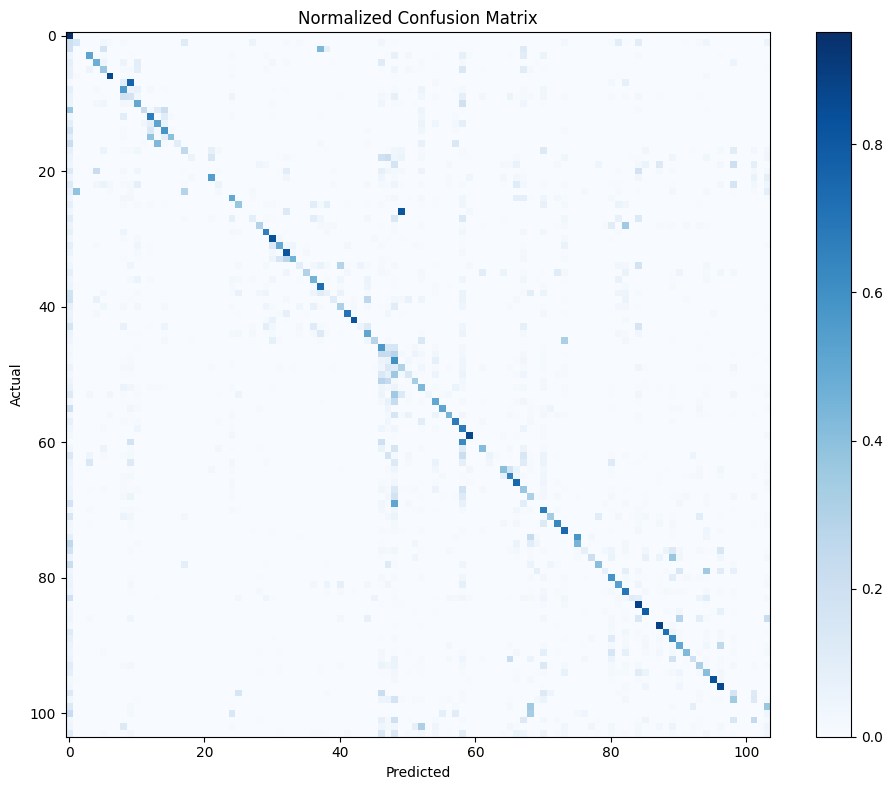

In [20]:
cm = results["confusion_matrix"].astype(float)

# normalize per row (actual class)
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-7)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, cmap="Blues")
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()


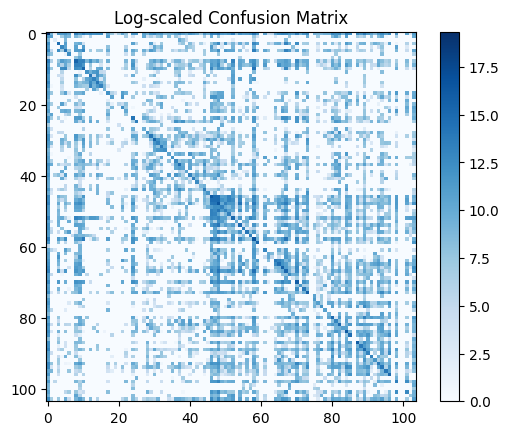

In [21]:

import numpy as np

cm_log = np.log1p(cm)

plt.imshow(cm_log, cmap="Blues")
plt.title("Log-scaled Confusion Matrix")
plt.colorbar()
plt.show()

**Final test evaluation (report this mIoU)**

In [22]:
ckpt = torch.load("best_deeplabv3plus_mnv2_foodseg103.pth", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

test_ious = []
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        preds = torch.argmax(logits, dim=1)
        for b in range(preds.shape[0]):
            test_ious.append(batch_iou(preds[b], masks[b], NUM_CLASSES))

print("FINAL TEST mIoU:", float(np.mean(test_ious)))


FINAL TEST mIoU: 0.3054910045711322


**Inference + visualization on 1 test image**

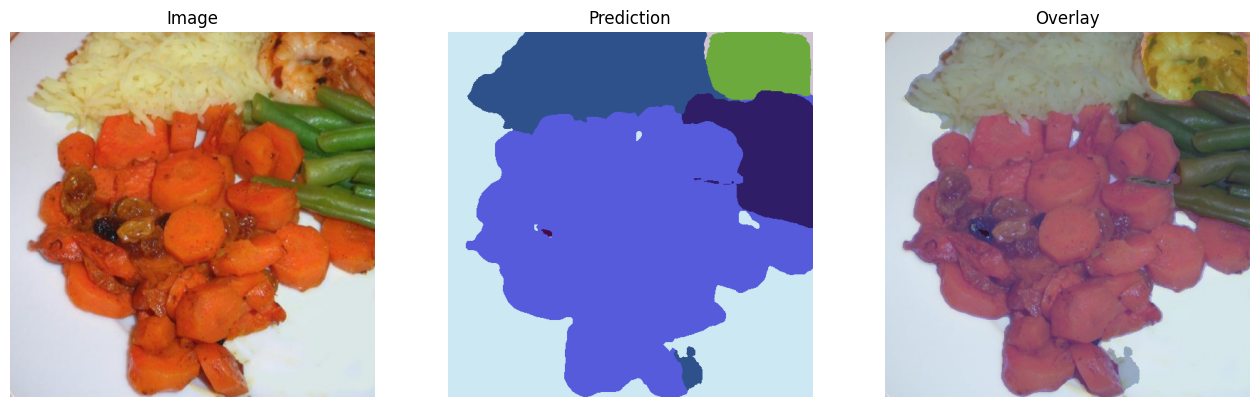

In [23]:
import cv2
import numpy as np
import torch


def colorize_mask(mask, num_classes, seed=123):
    """
    Convert a segmentation mask (H,W) into a color image (H,W,3)
    """
    rng = np.random.default_rng(seed)
    colors = rng.integers(0, 255, size=(num_classes, 3), dtype=np.uint8)
    return colors[mask]


def predict_one(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # apply same transform (resize to 512x512)
    out = val_tfms(image=img, mask=np.zeros((img.shape[0], img.shape[1]), dtype=np.int64))
    x = out["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    # IMPORTANT: use resized image (512x512) for overlay
    img_resized = (out["image"].cpu().numpy().transpose(1,2,0))  # normalized float
    # de-normalize for display (since you used A.Normalize with default mean/std)
    # albumentations default Normalize uses mean=(0,0,0), std=(1,1,1) unless you set it.
    # If you didn't set mean/std, then it's already 0-1 range but might not be.
    # Safest: just resize original image:
    img_resized = cv2.resize(img, (pred.shape[1], pred.shape[0]), interpolation=cv2.INTER_LINEAR)

    return img_resized, pred


test_img_path = test_pairs[0][0]
img_rgb, pred_mask = predict_one(test_img_path)

colored = colorize_mask(pred_mask, NUM_CLASSES)
overlay = (0.6*img_rgb + 0.4*colored).astype(np.uint8)

plt.figure(figsize=(16,5))
plt.subplot(1,3,1); plt.title("Image"); plt.imshow(img_rgb); plt.axis("off")
plt.subplot(1,3,2); plt.title("Prediction"); plt.imshow(colored); plt.axis("off")
plt.subplot(1,3,3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")
plt.show()


mIoU for this image: 0.5513927989678952


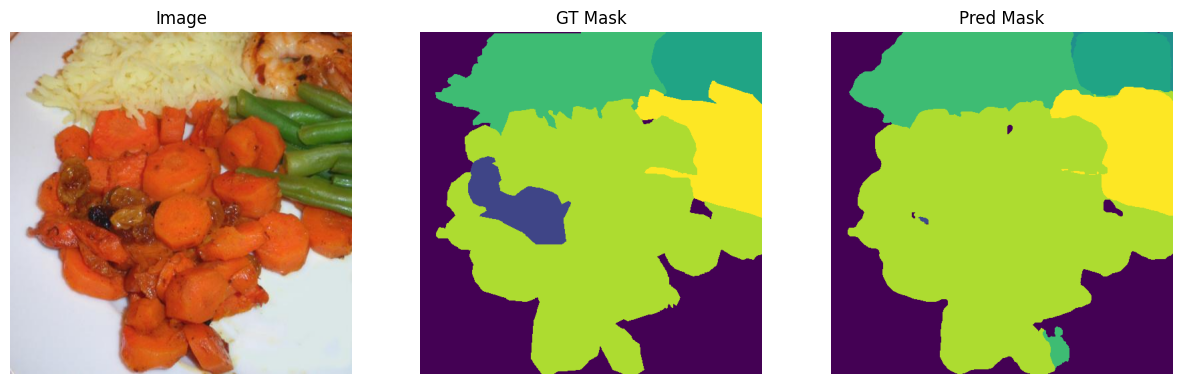

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch

def load_gt_mask(mask_path):
    m = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    if m.ndim == 3:
        m = cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)
    return m.astype(np.int64)

def predict_mask_only(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    out = val_tfms(image=img, mask=np.zeros((img.shape[0], img.shape[1]), dtype=np.int64))
    x = out["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.int64)

    img_resized = cv2.resize(img, (pred.shape[1], pred.shape[0]), interpolation=cv2.INTER_LINEAR)
    return img_resized, pred

def iou_for_class(pred, gt, cls):
    pred_i = (pred == cls)
    gt_i = (gt == cls)
    inter = np.logical_and(pred_i, gt_i).sum()
    union = np.logical_or(pred_i, gt_i).sum()
    if union == 0:
        return None
    return inter / union

def mean_iou(pred, gt, num_classes):
    ious = []
    for cls in range(num_classes):
        val = iou_for_class(pred, gt, cls)
        if val is not None:
            ious.append(val)
    return float(np.mean(ious)) if ious else 0.0

# pick a sample from test_pairs: (img_path, mask_path)
img_path, gt_path = test_pairs[0]

img_resized, pred = predict_mask_only(img_path)

# resize GT to same size as pred (important!)
gt = load_gt_mask(gt_path)
gt = cv2.resize(gt, (pred.shape[1], pred.shape[0]), interpolation=cv2.INTER_NEAREST)

miou_one = mean_iou(pred, gt, NUM_CLASSES)
print("mIoU for this image:", miou_one)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.title("Image"); plt.imshow(img_resized); plt.axis("off")
plt.subplot(1,3,2); plt.title("GT Mask"); plt.imshow(gt); plt.axis("off")
plt.subplot(1,3,3); plt.title("Pred Mask"); plt.imshow(pred); plt.axis("off")
plt.show()


In [25]:
unique, counts = np.unique(pred, return_counts=True)
top = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)[:10]
print("Top predicted classes (id, pixels):", top)
print("Num unique classes predicted:", len(unique))


Top predicted classes (id, pixels): [(np.int64(84), np.int64(120291)), (np.int64(0), np.int64(71114)), (np.int64(66), np.int64(36635)), (np.int64(96), np.int64(20998)), (np.int64(56), np.int64(12260)), (np.int64(48), np.int64(751)), (np.int64(21), np.int64(95))]
Num unique classes predicted: 7


In [26]:
import random

def quick_eval_samples(n=10):
    scores = []
    for _ in range(n):
        img_path, gt_path = random.choice(test_pairs)
        _, pred = predict_mask_only(img_path)

        gt = load_gt_mask(gt_path)
        gt = cv2.resize(gt, (pred.shape[1], pred.shape[0]), interpolation=cv2.INTER_NEAREST)

        scores.append(mean_iou(pred, gt, NUM_CLASSES))
    print(f"Avg mIoU over {n} random test images:", float(np.mean(scores)))

quick_eval_samples(10)


Avg mIoU over 10 random test images: 0.27846237688853004


**Load class names (FoodSeg103)**

In [27]:
import os

CATEGORY_FILE = os.path.join(DATA_ROOT, "category_id.txt")

def load_class_names(path):
    names = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            # handles: "0 background", "1 rice", etc.
            parts = s.replace(",", " ").split()
            if parts[0].isdigit():
                names.append(" ".join(parts[1:]))
            else:
                names.append(s)
    return names

CLASS_NAMES = load_class_names(CATEGORY_FILE)
print("Number of classes:", len(CLASS_NAMES))
print("Example:", CLASS_NAMES[:10])


Number of classes: 104
Example: ['background', 'candy', 'egg tart', 'french fries', 'chocolate', 'biscuit', 'popcorn', 'pudding', 'ice cream', 'cheese butter']


**Predict probabilities + segmentation mask (single image)**

In [28]:
import torch
import numpy as np
import cv2

def predict_probs_and_mask(image_path):
    # 1. read original image
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. apply SAME validation transform used during training/testing
    out = val_tfms(
        image=img,
        mask=np.zeros((img.shape[0], img.shape[1]), dtype=np.int64)
    )
    x = out["image"].unsqueeze(0).to(device)

    # 3. model prediction
    with torch.no_grad():
        logits = model(x)                      # [1,C,H,W]
        probs = torch.softmax(logits, dim=1)   # [1,C,H,W]

    # 4. convert to numpy
    probs = probs[0].cpu().numpy()             # [C,H,W]
    pred = np.argmax(probs, axis=0).astype(np.uint8)   # [H,W]

    # 5. return original image also
    return img, pred, probs

**clean_segmentation_mask, resize_mask_to_original, mask_quality_check**

In [29]:
import cv2
import numpy as np

def clean_segmentation_mask(mask):
    mask = (mask > 0).astype(np.uint8) * 255

    kernel = np.ones((5, 5), np.uint8)

    # remove noise
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # fill holes
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # keep largest connected component
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        cleaned = np.zeros_like(mask)
        cleaned[labels == largest_label] = 255
        mask = cleaned

    return mask

def resize_mask_to_original(mask, original_rgb):
    h, w = original_rgb.shape[:2]
    return cv2.resize(mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)

def mask_quality_check(mask):
    total = mask.size
    foreground = np.sum(mask > 0)
    ratio = foreground / total

    if ratio < 0.05 or ratio > 0.90:
        return False, ratio
    return True, ratio

**show results**

In [30]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def show_results(original_image, raw_mask, clean_mask):
    h, w = original_image.shape[:2]

    # resize masks if needed
    if raw_mask.shape[:2] != (h, w):
        raw_mask = cv2.resize(raw_mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)

    if clean_mask.shape[:2] != (h, w):
        clean_mask = cv2.resize(clean_mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)

    raw_bin = (raw_mask > 0).astype(np.uint8)
    clean_bin = (clean_mask > 0).astype(np.uint8)

    overlay = original_image.copy()
    overlay[clean_bin == 1] = [255, 0, 0]

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(raw_bin, cmap="gray")
    plt.title("Raw Mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(clean_bin, cmap="gray")
    plt.title("Clean Mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

**Core function: Detected foods + confidence**

In [31]:
def get_detected_foods(pred_mask, probs, class_names, min_area_frac=0.01):
    H, W = pred_mask.shape
    total_pixels = H * W
    results = []

    for cls_id in range(probs.shape[0]):
        mask = (pred_mask == cls_id)
        area = int(mask.sum())

        area_frac = area / total_pixels
        if area_frac < min_area_frac:
            continue

        if area == 0:
            continue

        confidence = float(probs[cls_id][mask].mean())
        label = class_names[cls_id] if cls_id < len(class_names) else f"class_{cls_id}"

        results.append({
            "class_id": cls_id,
            "label": label,
            "confidence": confidence,
            "area_fraction": area_frac
        })

    results.sort(key=lambda x: x["confidence"], reverse=True)
    return results

**Run it on a test image**

Mask foreground ratio: 0.729


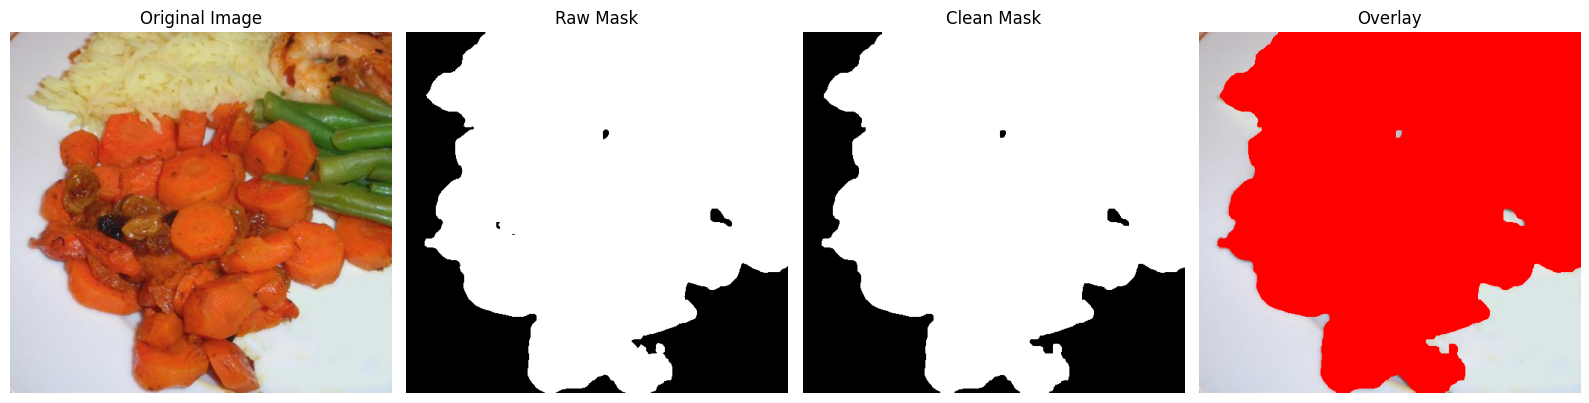

Detected foods:
{'class_id': 0, 'label': 'background', 'confidence': 0.9704991579055786, 'area_fraction': 0.2707710266113281}


In [32]:
img_path, _ = test_pairs[0]

original_img, pred_mask, probs = predict_probs_and_mask(img_path)

# clean the predicted mask
clean_mask = clean_segmentation_mask(pred_mask)

# quality check
ok, ratio = mask_quality_check(clean_mask)
print(f"Mask foreground ratio: {ratio:.3f}")
if not ok:
    print("Warning: segmentation may be unreliable")

# show visual results
show_results(original_img, pred_mask, clean_mask)

# detected foods from cleaned mask
detected_foods = get_detected_foods(
    clean_mask,
    probs,
    CLASS_NAMES,
    min_area_frac=0.01
)

print("Detected foods:")
for item in detected_foods:
    print(item)

**Return JSON for next phases**

In [33]:
import json

with open("detected_foods.json", "w") as f:
    json.dump(detected_foods, f, indent=2)

print("Saved detected_foods.json")


Saved detected_foods.json


**Single unseen image segmentation**

In [34]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

def segment_single_unseen_image(image_path, threshold=0.4):
    model.eval()

    # Read original image
    img = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Apply the same validation transform used in training/testing
    out = val_tfms(
        image=img,
        mask=np.zeros((img.shape[0], img.shape[1]), dtype=np.int64)
    )
    x = out["image"].unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        logits = model(x)

        # Multi-class segmentation
        if logits.shape[1] > 1:
            probs = torch.softmax(logits, dim=1)
            pred_mask = torch.argmax(probs, dim=1)[0].cpu().numpy().astype(np.uint8)

        # Binary segmentation
        else:
            probs = torch.sigmoid(logits)
            pred_mask = (probs[0, 0].cpu().numpy() > threshold).astype(np.uint8)

    return img, pred_mask

**Clean Mask**

In [35]:
def clean_segmentation_mask(mask):
    mask = (mask > 0).astype(np.uint8) * 255

    kernel = np.ones((5, 5), np.uint8)

    # Remove small noise
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Fill small holes
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Keep only the largest connected component
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        cleaned = np.zeros_like(mask)
        cleaned[labels == largest_label] = 255
        mask = cleaned

    return mask

**Resize mask back to original image size**

In [36]:
def resize_mask_to_original(mask, original_img):
    h, w = original_img.shape[:2]
    resized_mask = cv2.resize(mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
    return resized_mask

**Simple mask quality check**

In [37]:
def mask_quality_check(mask):
    total_pixels = mask.size
    foreground_pixels = np.sum(mask > 0)
    ratio = foreground_pixels / total_pixels

    if ratio < 0.05 or ratio > 0.90:
        return False, ratio
    return True, ratio

**Show result**

In [38]:
def show_segmentation_result(original_img, raw_mask, clean_mask):
    raw_bin = (raw_mask > 0).astype(np.uint8)
    clean_bin = (clean_mask > 0).astype(np.uint8)

    overlay = original_img.copy()
    overlay[clean_bin == 1] = [255, 0, 0]

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(raw_bin, cmap="gray")
    plt.title("Raw Mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(clean_bin, cmap="gray")
    plt.title("Clean Mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

**Run one unseen image**

Mask foreground ratio: 0.521


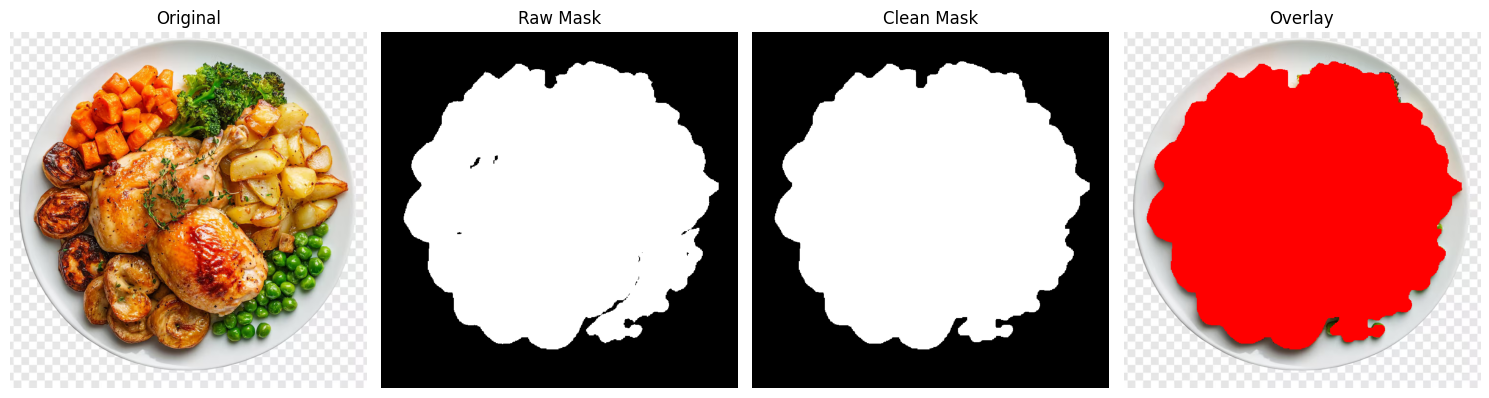

In [39]:
test_image = "/kaggle/input/datasets/rkr2001/unseen-data-seg/dinner-plate.png"

original_img, raw_mask = segment_single_unseen_image(test_image)
clean_mask = clean_segmentation_mask(raw_mask)

# Resize masks back to original image size
raw_mask_resized = resize_mask_to_original(raw_mask, original_img)
clean_mask_resized = resize_mask_to_original(clean_mask, original_img)

ok, ratio = mask_quality_check(clean_mask_resized)
print(f"Mask foreground ratio: {ratio:.3f}")
if not ok:
    print("Warning: segmentation may be unreliable")

show_segmentation_result(original_img, raw_mask_resized, clean_mask_resized)

**Run multiple unseen images**


Testing: /kaggle/input/datasets/rkr2001/unseen-data-seg/dinner-plate.png
Mask foreground ratio: 0.521


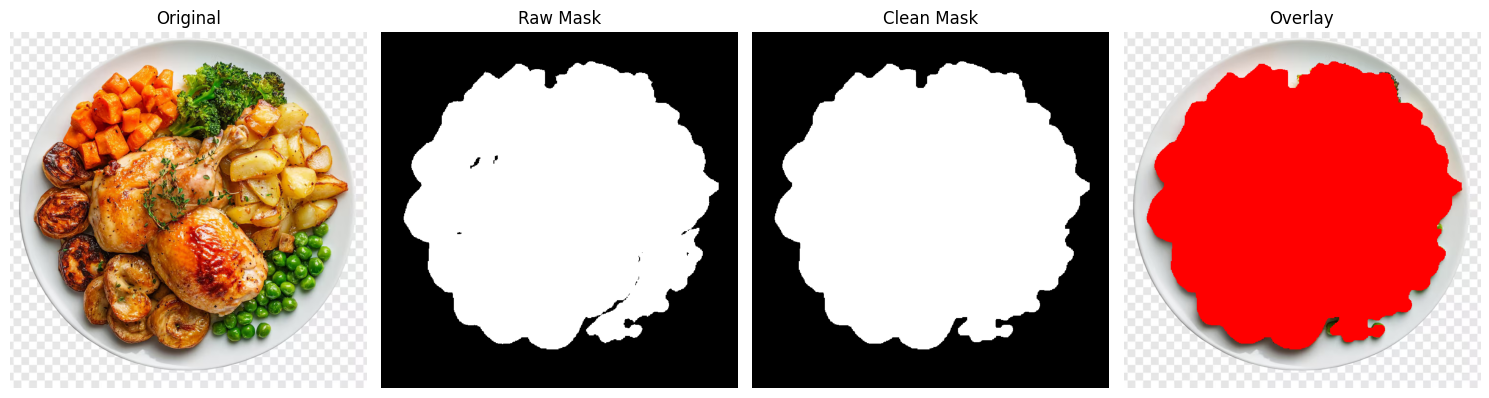


Testing: /kaggle/input/datasets/rkr2001/unseen-data-seg/cake.jpg
Mask foreground ratio: 0.341


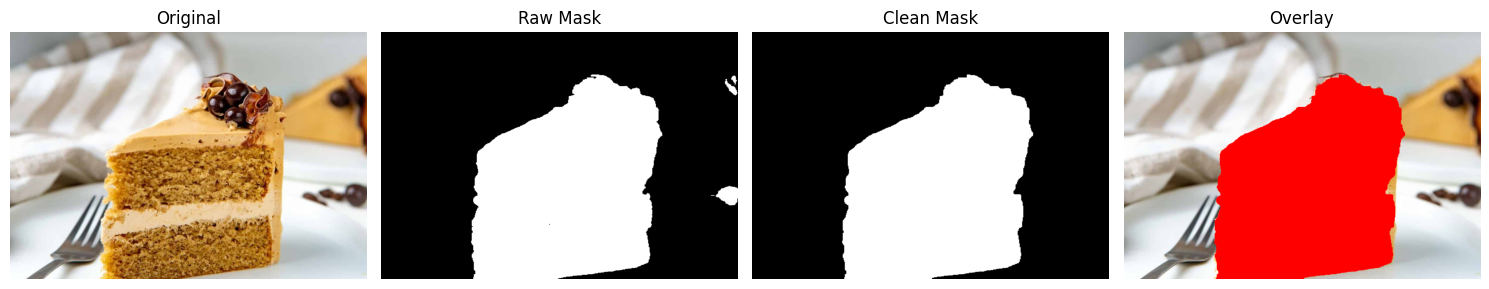


Testing: /kaggle/input/datasets/rkr2001/unseen-data-seg/chicken.jpg
Mask foreground ratio: 0.319


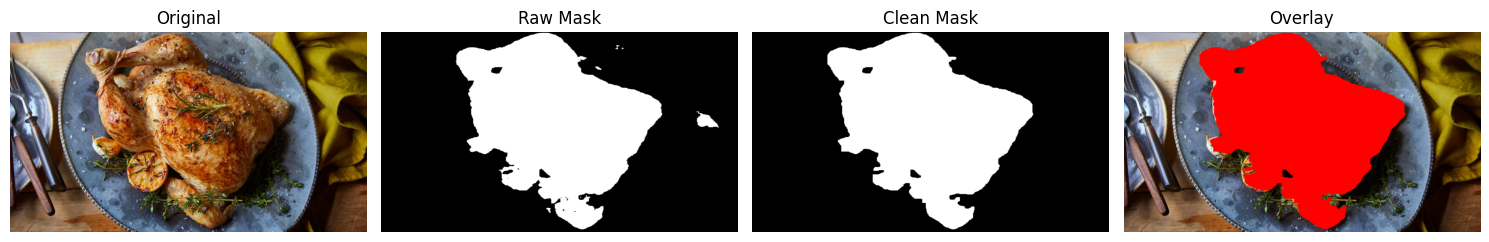


Testing: /kaggle/input/datasets/rkr2001/unseen-data-seg/fruit-plate.png
Mask foreground ratio: 0.248


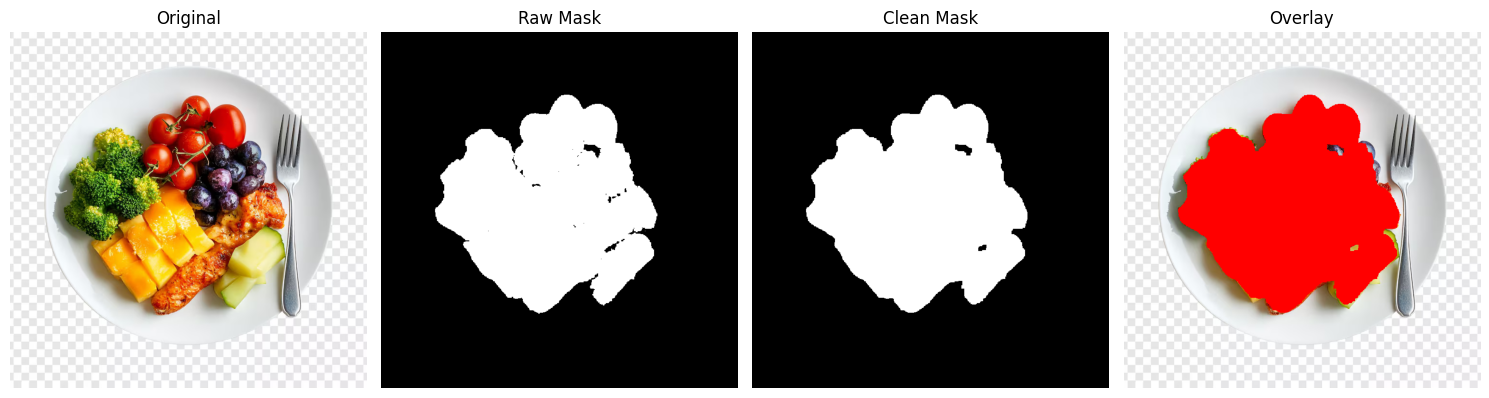


Testing: /kaggle/input/datasets/rkr2001/unseen-data-seg/ice cream.jpg
Mask foreground ratio: 0.298


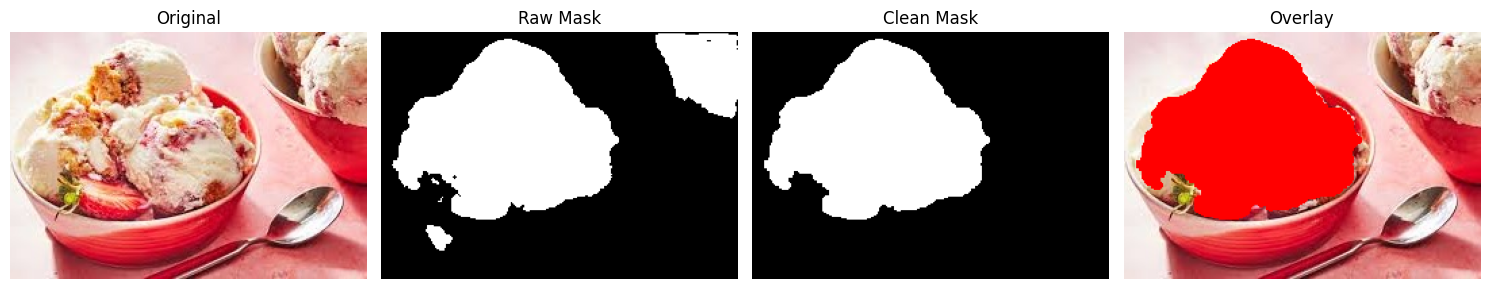

In [40]:
test_images = [
    "/kaggle/input/datasets/rkr2001/unseen-data-seg/dinner-plate.png",
    "/kaggle/input/datasets/rkr2001/unseen-data-seg/cake.jpg",
    "/kaggle/input/datasets/rkr2001/unseen-data-seg/chicken.jpg",
    "/kaggle/input/datasets/rkr2001/unseen-data-seg/fruit-plate.png",
    "/kaggle/input/datasets/rkr2001/unseen-data-seg/ice cream.jpg"
]

for img_path in test_images:
    print("\n" + "=" * 50)
    print("Testing:", img_path)

    try:
        original_img, raw_mask = segment_single_unseen_image(img_path)
        clean_mask = clean_segmentation_mask(raw_mask)

        raw_mask_resized = resize_mask_to_original(raw_mask, original_img)
        clean_mask_resized = resize_mask_to_original(clean_mask, original_img)

        ok, ratio = mask_quality_check(clean_mask_resized)
        print(f"Mask foreground ratio: {ratio:.3f}")
        if not ok:
            print("Warning: segmentation may be unreliable")

        show_segmentation_result(original_img, raw_mask_resized, clean_mask_resized)

    except Exception as e:
        print("Error:", e)